In [1]:
import mne
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

# Add the root directory to the system path to allow config imports
sys.path.append(os.path.abspath("../"))
import config

# List of datasets to inspect
DATASETS = ["FM_EO_dataset", "CP_FM_dataset", "TDBRAIN-dataset", "Chronicpainset"]

In [2]:
def inspect_dataset(dataset_name):
    """Finds the first available .fif file and visualizes the data."""
    # Use paths from config.py to maintain folder structure abstraction
    dataset_path = config.PROCESSED_DATA_DIR / "riemannian" / dataset_name
    files = list(dataset_path.glob("*_riemann.fif"))
    
    if not files:
        print(f"► Dataset {dataset_name}: No files found.")
        return None

    return files[0] # Return the first file for inspection

In [3]:
def plot_data(file_path, dataset_name):
    """Loads data and generates waveform and PSD plots with dataset identification."""
    epochs = mne.read_epochs(file_path, preload=True, verbose='ERROR')
    
    print(f"► Dataset: {dataset_name} | File: {file_path.name}")
    print(f"  ✓ Total epochs: {len(epochs)}")
    print(f"  ✓ Total channels: {len(epochs.ch_names)}")
    
    # Create the average object
    evoked = epochs.average()
    
    # Generate the waveform plot
    # We remove the 'title' argument to prevent the TypeError
    fig = evoked.plot(spatial_colors=True, gfp=True)
    
    # Manually set the title on the figure object
    fig.suptitle(f"Average Epoch - {dataset_name}", fontsize=14)
    
    # PSD plot to verify the 0.5 - 44 Hz filter
    epochs.compute_psd(fmin=0.1, fmax=50).plot(spatial_colors=True, show=True)

► Dataset: FM_EO_dataset | File: sub-FM001_task-EO_eeg_riemann.fif
  ✓ Total epochs: 95
  ✓ Total channels: 19


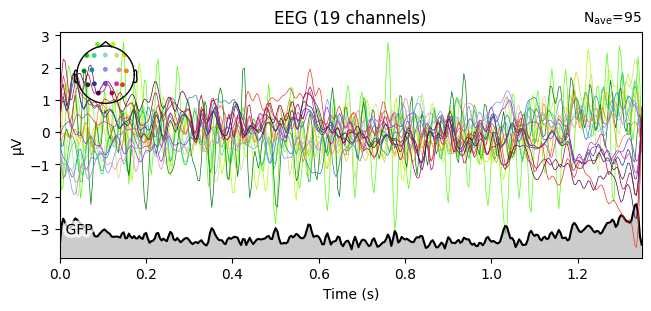

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: CP_FM_dataset | File: Chronic_painEyesClosed_HC_01_elementary_data_riemann.fif
  ✓ Total epochs: 282
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


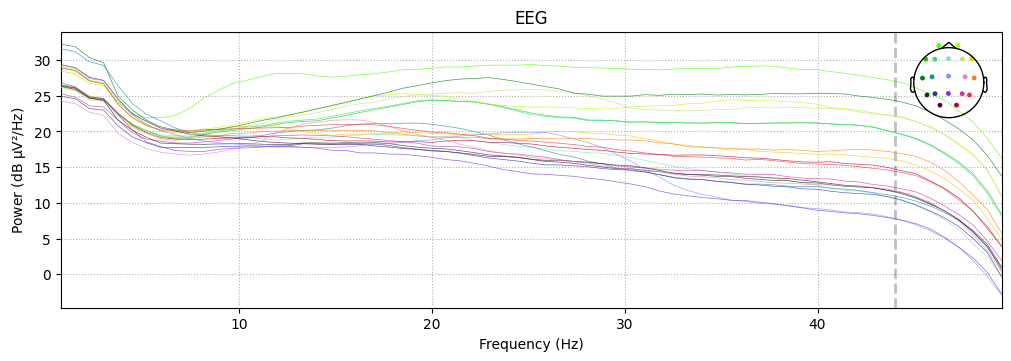

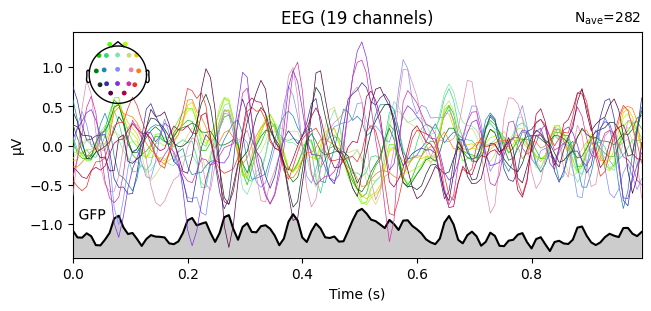

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: TDBRAIN-dataset | File: sub-87974617_ses-1_task-restEC_eeg_riemann.fif
  ✓ Total epochs: 110
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


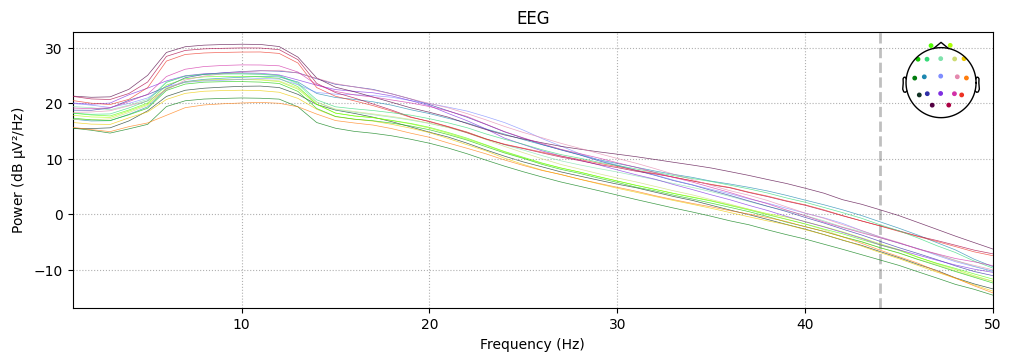

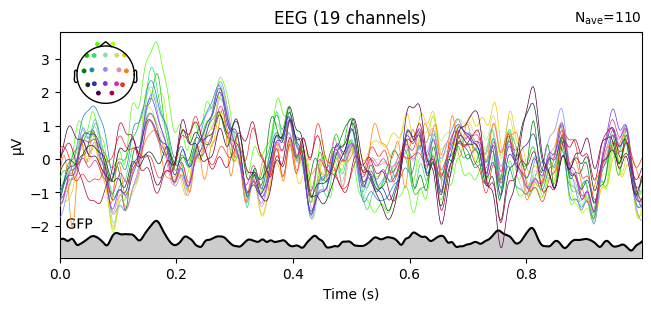

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: Chronicpainset | File: sub-001_task-EC_eeg_new_riemann.fif
  ✓ Total epochs: 297
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


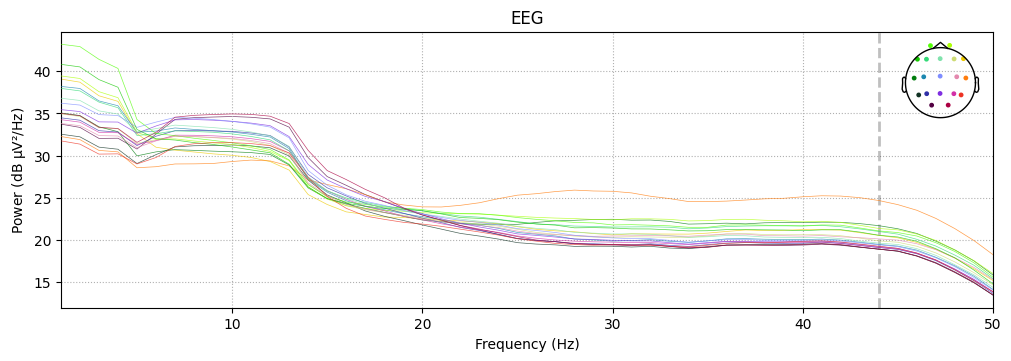

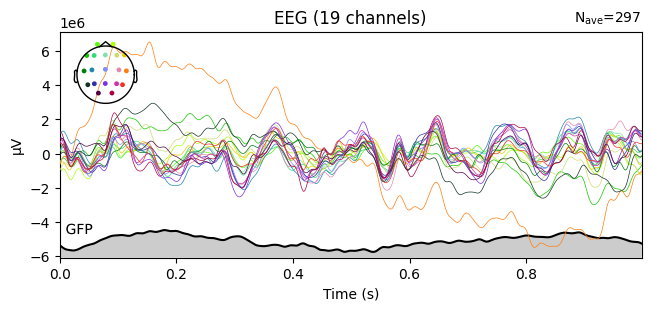

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


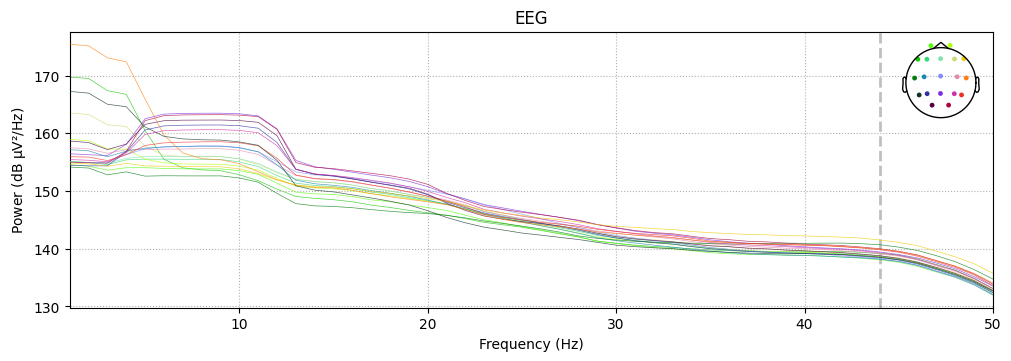

In [4]:
if __name__ == "__main__":
    for ds in DATASETS:
        target_file = inspect_dataset(ds)
        if target_file:
            # Pass the dataset name to the plotting function
            plot_data(target_file, ds)

In [5]:
def plot_data(file_path, dataset_name):
    """Loads data and generates waveform and PSD plots with dataset identification."""
    epochs = mne.read_epochs(file_path, preload=True, verbose='ERROR')
    
    print(f"► Dataset: {dataset_name} | File: {file_path.name}")
    print(f"  ✓ Total epochs: {len(epochs)}")
    print(f"  ✓ Total channels: {len(epochs.ch_names)}")
    
    # Create the average object
    evoked = epochs.average()
    evoked.plot_image(titles={'eeg': 'Channel Traces per Dataset'}, show_names=True)
    evoked.plot(spatial_colors=True, gfp=True, picks='all')
    
    
    # Generate the waveform plot
    # We remove the 'title' argument to prevent the TypeError
    fig = evoked.plot(spatial_colors=True, gfp=True)
    
    # Manually set the title on the figure object
    fig.suptitle(f"Average Epoch - {dataset_name}", fontsize=14)
    
    # PSD plot to verify the 0.5 - 44 Hz filter
    epochs.compute_psd(fmin=0.1, fmax=50).plot(spatial_colors=True, show=True)

► Dataset: FM_EO_dataset | File: sub-FM001_task-EO_eeg_riemann.fif
  ✓ Total epochs: 95
  ✓ Total channels: 19


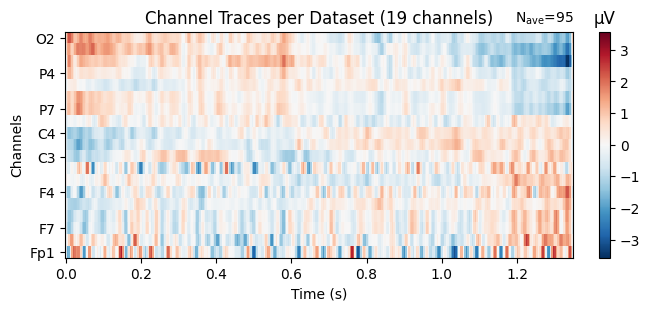

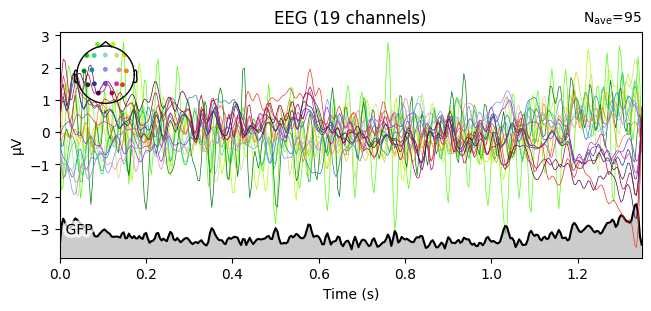

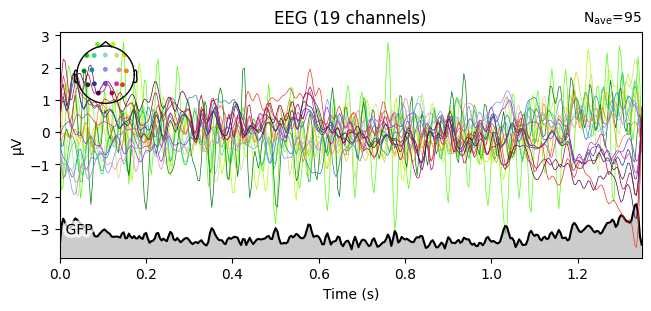

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: CP_FM_dataset | File: Chronic_painEyesClosed_HC_01_elementary_data_riemann.fif
  ✓ Total epochs: 282
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


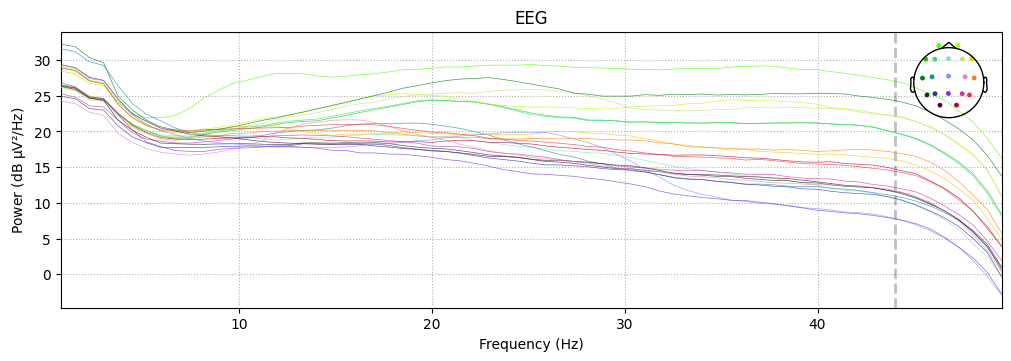

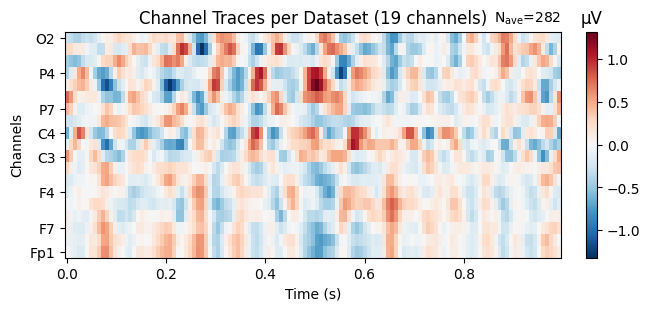

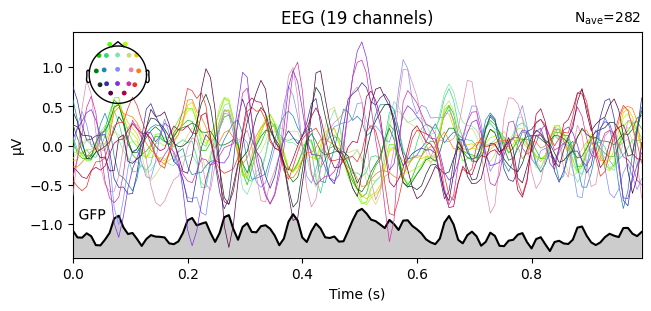

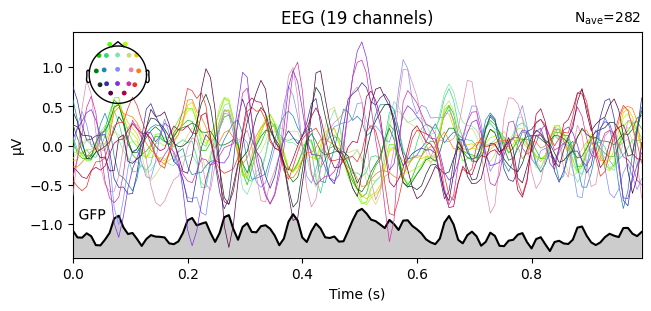

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: TDBRAIN-dataset | File: sub-87974617_ses-1_task-restEC_eeg_riemann.fif
  ✓ Total epochs: 110
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


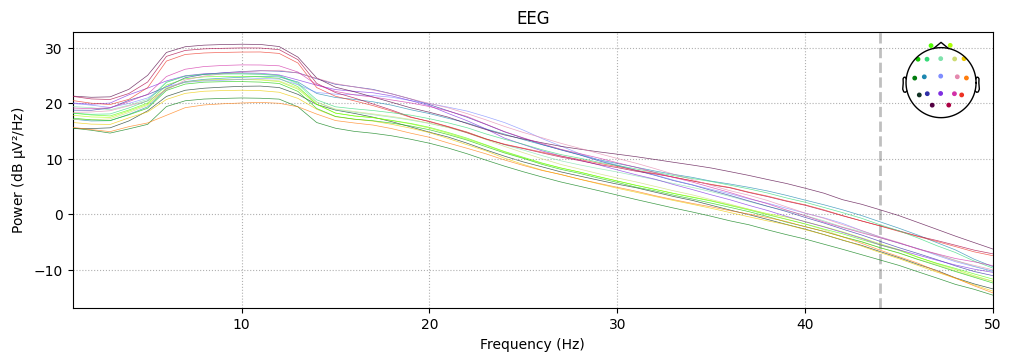

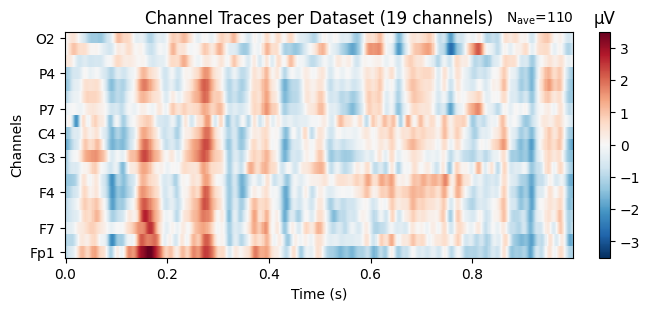

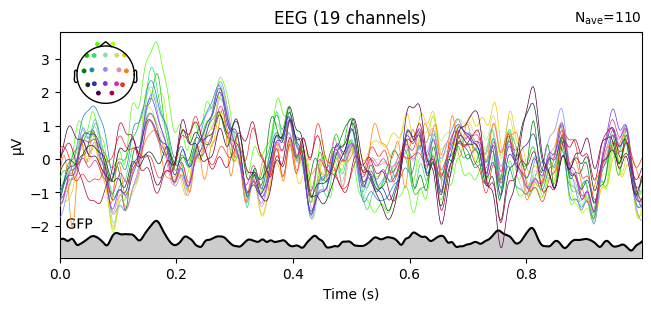

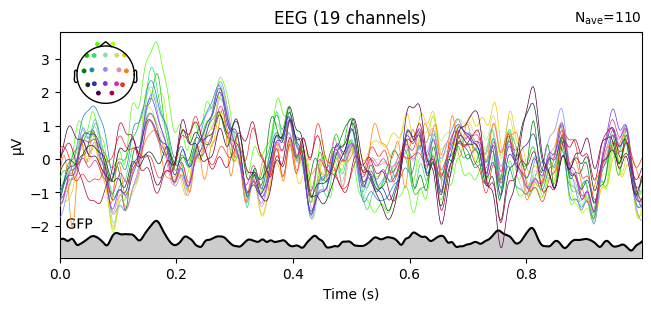

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
► Dataset: Chronicpainset | File: sub-001_task-EC_eeg_new_riemann.fif
  ✓ Total epochs: 297
  ✓ Total channels: 19


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


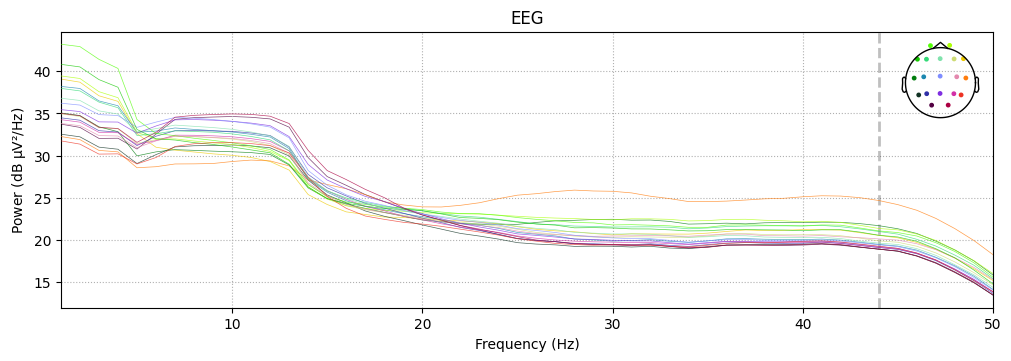

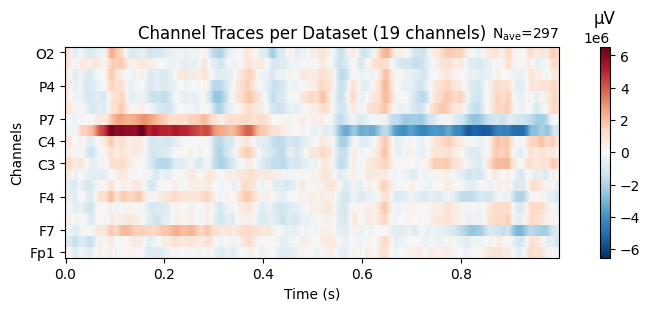

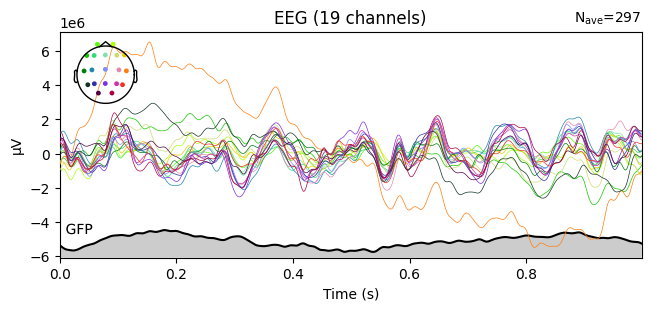

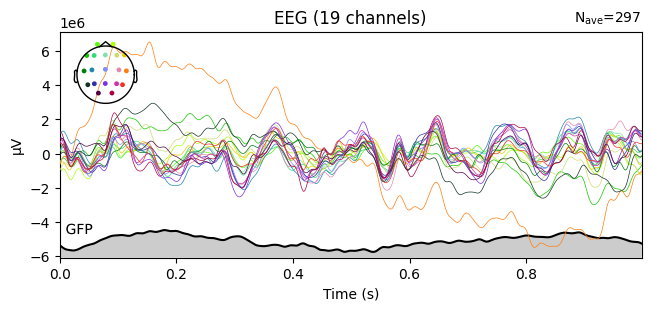

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


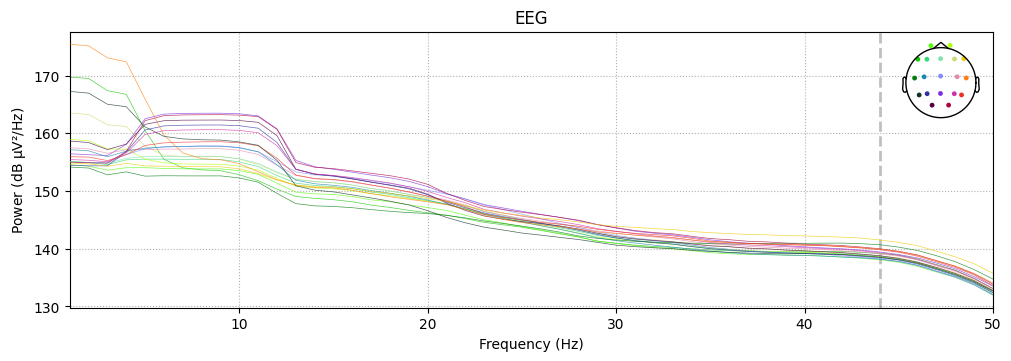

In [6]:
if __name__ == "__main__":
    for ds in DATASETS:
        target_file = inspect_dataset(ds)
        if target_file:
            # Pass the dataset name to the plotting function
            plot_data(target_file, ds)